In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import cv2
from pathlib import Path
from collections import Counter

# Google Drive Dataset Path
DATASET_ROOT = Path("/content/drive/MyDrive/Gloves_det_Project/dataset")

SPLITS = ["train", "valid", "test"]
IMAGE_EXTS = [".jpg", ".jpeg", ".png"]

def get_images(folder):
    images = []
    for ext in IMAGE_EXTS:
        images.extend(folder.rglob(f"*{ext}"))
    return images

print(" Dataset Validation ")

total_images = 0
class_counter = Counter()

missing_labels = []
missing_images = []
corrupt_images = []
empty_labels = []

for split in SPLITS:

    print(f"Split : {split}")

    image_dir = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"

    images = get_images(image_dir)

    print(f"Images : {len(images)}")

    total_images += len(images)

    for img_path in images:

        label_path = label_dir / f"{img_path.stem}.txt"

        # Corrupt image
        if cv2.imread(str(img_path)) is None:
            corrupt_images.append(str(img_path))
            continue

        # Missing label
        if not label_path.exists():
            missing_labels.append(str(label_path))
            continue

        # Empty label
        lines = label_path.read_text().strip().splitlines()

        if len(lines) == 0:
            empty_labels.append(str(label_path))
            continue

        for line in lines:
            class_counter[int(line.split()[0])] += 1

    # Missing image check
    for label in label_dir.glob("*.txt"):

        if not any((image_dir / f"{label.stem}{ext}").exists() for ext in IMAGE_EXTS):
            missing_images.append(str(label))

    print()

print(f"Total Images : {total_images}\n")

CLASS_NAMES = {
    0: "gloved_hand",
    1: "bare_hand"
}

print("Class Distribution")
for cls, count in sorted(class_counter.items()):
    print(f"{CLASS_NAMES[cls]:15} : {count}")

print("\nDataset Issues")
print(f"Missing Labels : {len(missing_labels)}")
print(f"Missing Images : {len(missing_images)}")
print(f"Empty Labels   : {len(empty_labels)}")
print(f"Corrupt Images : {len(corrupt_images)}")

if empty_labels:
    print("\nEmpty Label Files:")
    for file in empty_labels:
        print(file)

 Dataset Validation 
Split : train
Images : 295

Split : valid
Images : 83

Split : test
Images : 31

Total Images : 409

Class Distribution
gloved_hand     : 258
bare_hand       : 476

Dataset Issues
Missing Labels : 0
Missing Images : 12
Empty Labels   : 1
Corrupt Images : 0

Empty Label Files:
/content/drive/MyDrive/Gloves_det_Project/dataset/valid/labels/IMG_5636_MOV-82_jpg.rf.eDZX32iqjgyIubSAlj5H.txt


Here one label is missing. Finding the path of that file and showing


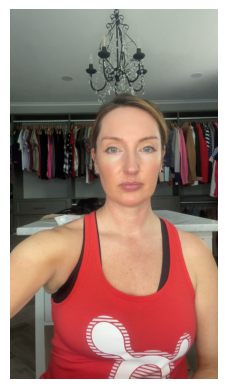

In [9]:
import cv2
import matplotlib.pyplot as plt

# Corrected path to point to the image in the 'images' directory
img = cv2.imread("/content/drive/MyDrive/Gloves_det_Project/dataset/valid/images/IMG_5636_MOV-82_jpg.rf.eDZX32iqjgyIubSAlj5H.jpg")


img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

Any of the lable 0 or 1 is not found here.
